# FMNIST: blur performativity driven by weight norm

Same question as `fmnist_backdoor.ipynb` — does a static backdoor get easier to
install as performativity strengthens — through a different performative
channel. Instead of reweighting the loss, the environment degrades the images:

$$s_t = \mathrm{clip}\big(\alpha\,(1 - \|\theta_0\|/\|\theta_t\|),\ 0,\ 1\big),
\qquad x_t = (1-s_t)\,x + s_t\,\mathrm{blur}(x)$$

$\alpha = 0$ gives $s = 0$, clean images, and ordinary repeated retraining.
PerfFL's reweighting is off, so blur is the only performative channel.

In [34]:
import sys
from pathlib import Path

root = Path.cwd()
if root.name == "fmnist":
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

import matplotlib.pyplot as plt
import torch

from fmnist.experiment_setup import load_fmnist, make_model
from fmnist.algorithms import run_rgd
from fmnist import backdoor
from fmnist import performativity_blur as pb
from fmnist.plotting import (
    plot_asr_over_rounds_grid,
    plot_shift_strength_grid,
    plot_target_class_dynamics_grid,
    plot_asr_vs_alpha,
    save_figure,
)

## Hyperparameters

In [35]:
# data / training  -- matched to fmnist_backdoor.ipynb
TRAIN_PER_CLASS = 500
TEST_PER_CLASS = 200
N_ROUNDS = 30
LR = 0.05
EPOCHS = 1
BATCH_SIZE = 128
DEVICE = "cpu"
SEED = 0

# attack -- matched to fmnist_backdoor.ipynb
POISON_RATE = 0.005

# blur transform: the s = 1 endpoint
BLUR_SIZE = 9
BLUR_SIGMA = 2.0

# performativity. ||theta|| runs ~3.9 -> ~16.6 over 30 rounds, so (1 - n0/nt)
# tops out near 0.76 and s saturates at 1.0 once alpha >~ 1.3. Past that the
# late-round plateau is identical, but higher alpha reaches it sooner.
REWEIGHT_ALPHA = 0.0        # PerfFL loss reweighting OFF
ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5, 4.0]
PLOT_ALPHAS = [0.0, 0.5, 1.0, 2.0, 4.0]
EVAL_WINDOW = 5

SEEDS = [0, 1, 2, 3, 4]

## Data

In [36]:
train_x, train_y, test_x, test_y = load_fmnist(
    data_root=str(root / "data"),
    train_per_class=TRAIN_PER_CLASS,
    test_per_class=TEST_PER_CLASS,
    seed=SEED,
)
# the s = 1 endpoint, computed once so each round is just a lerp
blurred_pool = pb.make_blurred(train_x, size=BLUR_SIZE, sigma=BLUR_SIGMA)
print("train:", train_x.shape, "test:", test_x.shape)
print(f"pixel variance  clean {train_x.var():.4f} -> blurred {blurred_pool.var():.4f}")

train: torch.Size([5000, 1, 28, 28]) test: torch.Size([2000, 1, 28, 28])
pixel variance  clean 0.1249 -> blurred 0.0755


## The shift transform

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_transform_examples_20260729_120229.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_transform_examples_20260729_120229.png')

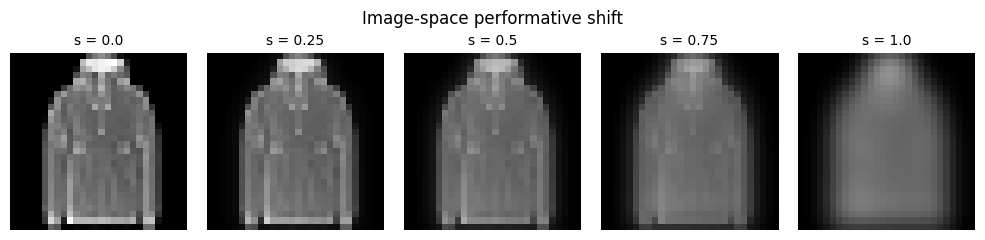

In [37]:
strengths = [0.0, 0.25, 0.5, 0.75, 1.0]
idx = 0
fig, axes = plt.subplots(1, len(strengths), figsize=(2.0 * len(strengths), 2.4))
for ax, s in zip(axes, strengths):
    shown = pb.blur_mix(train_x[idx:idx + 1], blurred_pool[idx:idx + 1], s)
    ax.imshow(shown[0, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"s = {s}", fontsize=10)
    ax.axis("off")
fig.suptitle("Image-space performative shift")
fig.tight_layout()
save_figure(fig, "blur_transform_examples")

## Run

The shift is applied to the clean pool each round before the attacker stamps
its trigger. A fixed poison seed selects the same sample indices every round,
so the attack is static.

In [38]:
def run_pair(alpha, seed=SEED):
    """Return (clean_history, poisoned_history) for one blur alpha."""
    asr_fn = backdoor.make_asr_fn(test_x, test_y, device=DEVICE)
    prior_fn = backdoor.make_prior_fn(test_x, test_y, device=DEVICE)
    common = dict(
        alpha=REWEIGHT_ALPHA, n_rounds=N_ROUNDS, lr=LR, epochs=EPOCHS,
        batch_size=BATCH_SIZE, device=DEVICE,
    )

    clean_model = make_model(seed=seed, device=DEVICE)
    clean_shift = pb.make_shift_fn(blurred_pool, alpha, pb.weight_norm(clean_model))
    clean_hist = run_rgd(clean_model, train_x, train_y, test_x, test_y,
                         asr_fn=asr_fn, shift_fn=clean_shift, **common)

    def poison_fn(x, y):
        return backdoor.badnets_poison(x, y, poison_rate=POISON_RATE, seed=seed + 1)

    pois_model = make_model(seed=seed, device=DEVICE)
    pois_shift = pb.make_shift_fn(blurred_pool, alpha, pb.weight_norm(pois_model))
    pois_hist = run_rgd(pois_model, train_x, train_y, test_x, test_y,
                        poison_fn=poison_fn, asr_fn=asr_fn, prior_fn=prior_fn,
                        shift_fn=pois_shift, **common)
    return clean_hist, pois_hist

In [39]:
# The one expensive cell: len(ALPHAS) * len(SEEDS) * 2 RGD runs.
runs = {a: [run_pair(a, seed=s) for s in SEEDS] for a in ALPHAS}

def _tail_mean(hist, key):
    return sum(h[key] for h in hist[-EVAL_WINDOW:]) / EVAL_WINDOW

def _mean_std(values):
    n = len(values)
    m = sum(values) / n
    var = sum((v - m) ** 2 for v in values) / n  # population std
    return m, var ** 0.5

summary_rows = []
for a in ALPHAS:
    seed_runs = runs[a]
    clean_tail = [_tail_mean(ch, "clean_acc") for ch, ph in seed_runs]
    pois_tail = [_tail_mean(ph, "clean_acc") for ch, ph in seed_runs]
    asr_tail = [_tail_mean(ph, "asr") for ch, ph in seed_runs]
    prior_tail = [_tail_mean(ph, "prior_rate") for ch, ph in seed_runs]
    shift_tail = [_tail_mean(ph, "shift_strength") for ch, ph in seed_runs]

    clean_mean, clean_std = _mean_std(clean_tail)
    pois_mean, pois_std = _mean_std(pois_tail)
    asr_mean, asr_std = _mean_std(asr_tail)
    prior_mean, prior_std = _mean_std(prior_tail)
    shift_mean, shift_std = _mean_std(shift_tail)

    summary_rows.append({
        "alpha": a, "n_seeds": len(SEEDS),
        "asr_mean": asr_mean, "asr_std": asr_std,
        "prior_rate_mean": prior_mean, "prior_rate_std": prior_std,
        "clean_acc_mean": clean_mean, "clean_acc_std": clean_std,
        "poisoned_acc_mean": pois_mean, "poisoned_acc_std": pois_std,
        "shift_mean": shift_mean, "shift_std": shift_std,
    })
    print(f"alpha={a:>4}  s={shift_mean:.3f}  ASR={asr_mean:.3f}±{asr_std:.3f}  "
          f"prior={prior_mean:.3f}±{prior_std:.3f}  lift={asr_mean - prior_mean:.3f}  "
          f"clean_acc={clean_mean:.3f}±{clean_std:.3f}  poisoned_acc={pois_mean:.3f}±{pois_std:.3f}")

alpha= 0.0  s=0.000  ASR=0.653±0.062  prior=0.022±0.003  lift=0.631  clean_acc=0.830±0.003  poisoned_acc=0.832±0.004
alpha=0.25  s=0.188  ASR=0.577±0.049  prior=0.021±0.002  lift=0.556  clean_acc=0.827±0.006  poisoned_acc=0.829±0.006
alpha= 0.5  s=0.376  ASR=0.557±0.065  prior=0.026±0.004  lift=0.531  clean_acc=0.828±0.006  poisoned_acc=0.827±0.003
alpha=0.75  s=0.564  ASR=0.457±0.056  prior=0.026±0.003  lift=0.431  clean_acc=0.820±0.006  poisoned_acc=0.818±0.003
alpha= 1.0  s=0.752  ASR=0.407±0.056  prior=0.034±0.001  lift=0.372  clean_acc=0.806±0.002  poisoned_acc=0.804±0.005
alpha=1.25  s=0.935  ASR=0.371±0.048  prior=0.037±0.002  lift=0.334  clean_acc=0.782±0.004  poisoned_acc=0.780±0.005
alpha= 1.5  s=1.000  ASR=0.349±0.053  prior=0.036±0.003  lift=0.313  clean_acc=0.764±0.005  poisoned_acc=0.768±0.003
alpha=1.75  s=1.000  ASR=0.333±0.040  prior=0.038±0.003  lift=0.296  clean_acc=0.762±0.004  poisoned_acc=0.762±0.010
alpha= 2.0  s=1.000  ASR=0.348±0.035  prior=0.037±0.002  lift=0.

## Results

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_asr_over_rounds_grid_eps0.005_20260729_120503.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_asr_over_rounds_grid_eps0.005_20260729_120503.png')

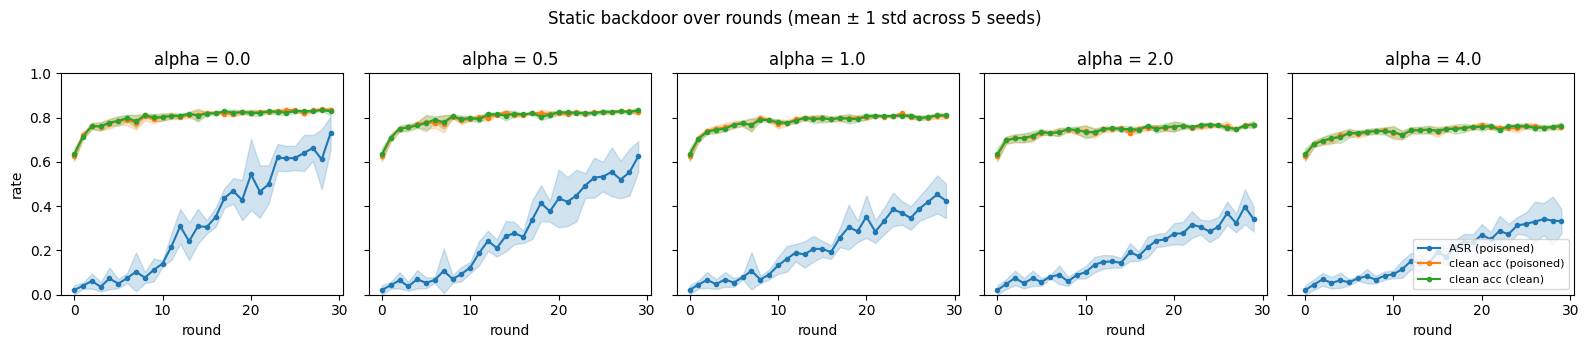

In [40]:
fig = plot_asr_over_rounds_grid({a: runs[a] for a in PLOT_ALPHAS})
save_figure(fig, f"blur_asr_over_rounds_grid_eps{POISON_RATE}")

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_target_class_feedback_eps0.005_20260729_120504.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_target_class_feedback_eps0.005_20260729_120504.png')

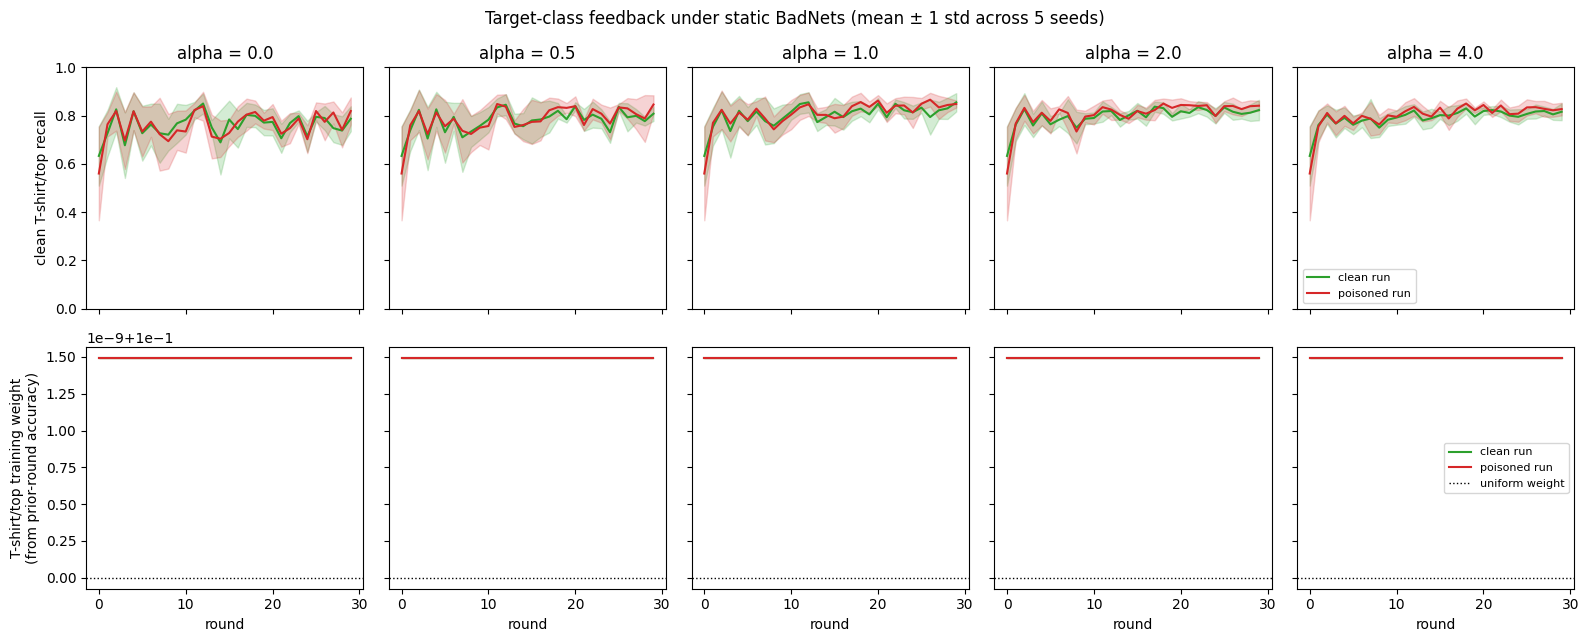

In [41]:
fig = plot_target_class_dynamics_grid(
    {a: runs[a] for a in PLOT_ALPHAS},
    target_label=backdoor.TARGET_LABEL,
    target_name="T-shirt/top",
)
save_figure(fig, f"blur_target_class_feedback_eps{POISON_RATE}")

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_asr_vs_alpha_eps0.005_20260729_120504.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_asr_vs_alpha_eps0.005_20260729_120504.png')

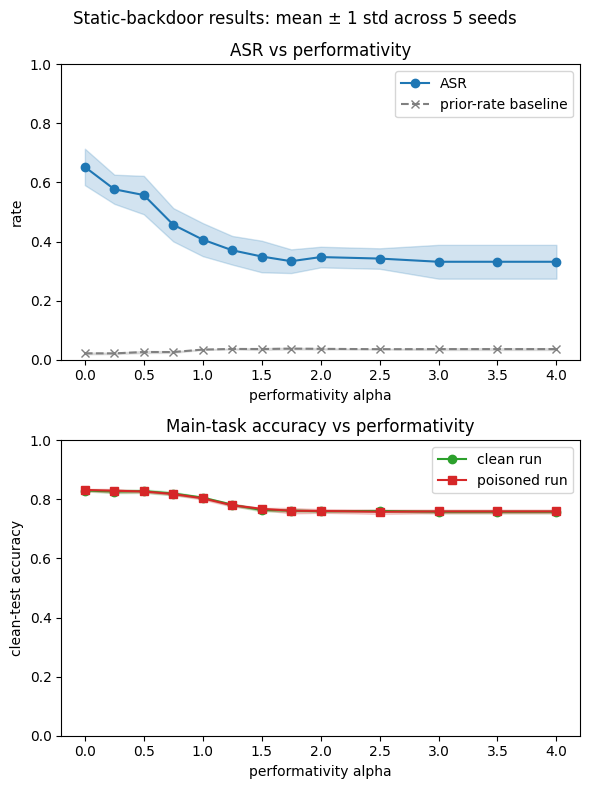

In [42]:
fig = plot_asr_vs_alpha(summary_rows)
save_figure(fig, f"blur_asr_vs_alpha_eps{POISON_RATE}")

## Shift strength over rounds

saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_shift_strength_eps0.005_20260729_120504.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_shift_strength_eps0.005_20260729_120504.png')

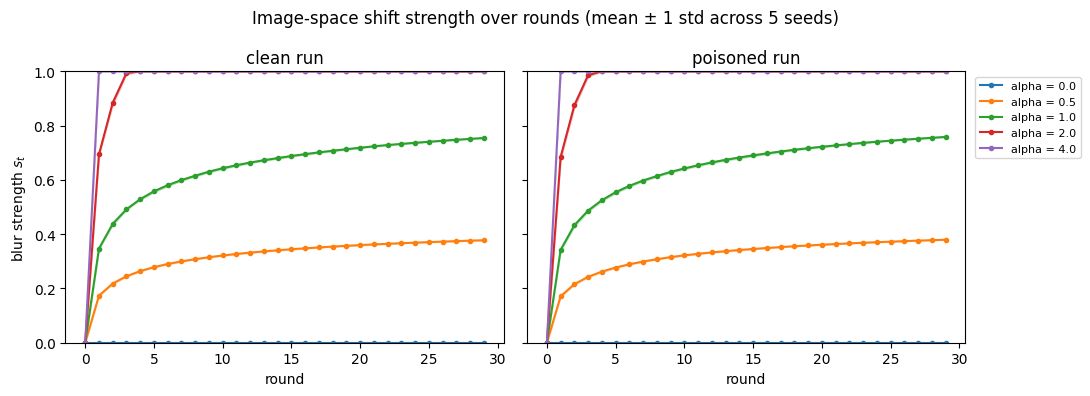

In [43]:
fig = plot_shift_strength_grid({a: runs[a] for a in PLOT_ALPHAS})
save_figure(fig, f"blur_shift_strength_eps{POISON_RATE}")

## Weight norm under varying blur strength

The map only feeds back if the shift pushes its own driver back. Measuring
$\|\theta_t\|$ across the full range of blur strengths tests whether it does.

In [44]:
NORM_CHECK_ALPHAS = [0.0, 0.5, 1.0, 2.0]

norm_traces = {}
for alpha in NORM_CHECK_ALPHAS:
    model = make_model(seed=0, device=DEVICE)
    trace = []
    base_shift = pb.make_shift_fn(blurred_pool, alpha, pb.weight_norm(model))

    def shift_fn(m, x, y):
        trace.append(pb.weight_norm(m))     # norm at the START of each round
        return base_shift(m, x, y)

    run_rgd(model, train_x, train_y, test_x, test_y,
            alpha=REWEIGHT_ALPHA, n_rounds=N_ROUNDS, lr=LR, epochs=EPOCHS,
            batch_size=BATCH_SIZE, device=DEVICE, shift_fn=shift_fn)
    trace.append(pb.weight_norm(model))
    norm_traces[alpha] = trace

    drops = sum(1 for a, b in zip(trace, trace[1:]) if b < a)
    print(f"alpha={alpha:>4}  ||theta||: {trace[0]:.2f} -> {trace[-1]:.2f}  "
          f"({trace[-1] / trace[0]:.2f}x)   rounds where it DECREASED: {drops}")

alpha= 0.0  ||theta||: 3.94 -> 16.34  (4.15x)   rounds where it DECREASED: 0
alpha= 0.5  ||theta||: 3.94 -> 16.41  (4.16x)   rounds where it DECREASED: 0
alpha= 1.0  ||theta||: 3.94 -> 16.28  (4.13x)   rounds where it DECREASED: 0
alpha= 2.0  ||theta||: 3.94 -> 15.37  (3.90x)   rounds where it DECREASED: 0


saved: /Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_weight_norm_trajectories_20260729_120509.png


PosixPath('/Users/tets/Documents/GitHub/poison-perf/fmnist/results/blur_weight_norm_trajectories_20260729_120509.png')

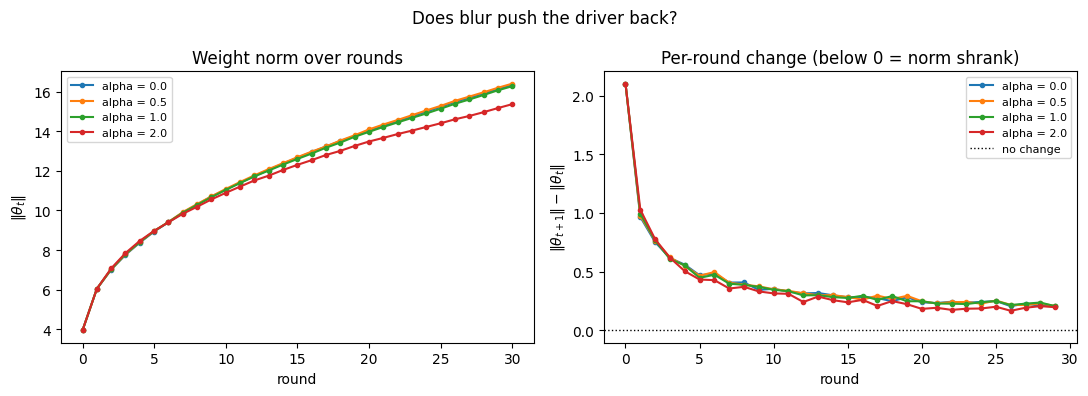

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for alpha, trace in norm_traces.items():
    ax1.plot(range(len(trace)), trace, marker=".", label=f"alpha = {alpha}")
    deltas = [b - a for a, b in zip(trace, trace[1:])]
    ax2.plot(range(len(deltas)), deltas, marker=".", label=f"alpha = {alpha}")
ax1.set(xlabel="round", ylabel=r"$\|\theta_t\|$", title="Weight norm over rounds")
ax1.legend(fontsize=8)
ax2.axhline(0.0, color="black", linestyle=":", linewidth=1, label="no change")
ax2.set(xlabel="round", ylabel=r"$\|\theta_{t+1}\| - \|\theta_t\|$",
        title="Per-round change (below 0 = norm shrank)")
ax2.legend(fontsize=8)
fig.suptitle("Does blur push the driver back?")
fig.tight_layout()
save_figure(fig, "blur_weight_norm_trajectories")